# 14 — Figures 4 & 5 (unexpected credit contraction: flex vs fixed FX)

**Ports**: `Code/MATLAB/Figures.m` lines 200–382.

**What we plot**: percent log-deviations of contraction-path aggregates from their period-41 expansion baseline values. `Tirf = 30` quarters.

**Figure 4 (2×2)**: Consumption of Home Goods, Consumption of Foreign Goods, Output, Investment.

**Figure 5 (2×2)**: Terms of Trade, Real Wage, Nominal Exchange Rate, Real Interest Rate.

Each subplot shows two paths:
* **flex** (solid blue) — from notebook 12 (`contraction_flex.npz`)
* **fixed** (dashed orange) — from notebook 13 (`contraction_fixed.npz`)

**Baselines** (scalars at $t = $ shock_start_t = 41 of the credit expansion):
* `ch_agg0 = c_t_agg[40]_exp`
* `cf_agg0 = (ω/(1-ω))·tot[40]_exp·c_t[40]_exp`
* `y_agg0 = y_agg[40]_exp`
* `inv0 = k_agg[40]_exp - (1-δ)·k_agg[39]_exp`
* `tot0 = tot[40]_exp`
* `w0 = w_r[40]_exp`
* `r0 = r_t[41]_exp`

In [1]:
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt

tic_total = time.perf_counter()

OUTPUT_DIR = Path('..') / 'output'
FIGS_DIR = Path('..') / '..' / '..' / 'Figures'   # repo-level Figures/
FIGS_DIR.mkdir(exist_ok=True)

p = np.load(OUTPUT_DIR / 'params.npz')
tr = np.load(OUTPUT_DIR / 'transition_flex.npz')
fl = np.load(OUTPUT_DIR / 'contraction_flex.npz')
fi = np.load(OUTPUT_DIR / 'contraction_fixed.npz')

omega = float(p['params__omega'])
delta = float(p['params__delta'])
shock_start_idx = int(tr['shock_start_idx'])      # = 40 (period 41 in 1-indexed)

# Baselines (from expansion at period 41 = idx 40)
ch_agg0 = float(tr['c_t_agg'][shock_start_idx])
cf_agg0 = omega / (1.0 - omega) * float(tr['tot'][shock_start_idx]) * float(tr['c_t'][shock_start_idx])
y_agg0 = float(tr['y_agg'][shock_start_idx])
inv0 = float(tr['k_agg'][shock_start_idx]) - (1.0 - delta) * float(tr['k_agg'][shock_start_idx - 1])
tot0 = float(tr['tot'][shock_start_idx])
w0 = float(tr['w_r'][shock_start_idx])
r0 = float(tr['r_t'][shock_start_idx + 1])

Tirf = 30
print(f'Tirf = {Tirf} quarters')
print(f'Baselines (from expansion at period 41):')
print(f'  ch_agg0 = {ch_agg0:.4f}')
print(f'  cf_agg0 = {cf_agg0:.4f}')
print(f'  y_agg0  = {y_agg0:.4f}')
print(f'  inv0    = {inv0:.4f}')
print(f'  tot0    = {tot0:.4f}')
print(f'  w0      = {w0:.4f}')
print(f'  r0      = {100*r0:.4f}% per quarter')

Tirf = 30 quarters
Baselines (from expansion at period 41):
  ch_agg0 = 1.4745
  cf_agg0 = 1.0075
  y_agg0  = 3.0422
  inv0    = 0.6244
  tot0    = 1.0249
  w0      = 1.8539
  r0      = 0.9675% per quarter


## Build the contraction series

MATLAB defines `Consumption_foreign_exp = (ω/(1-ω))·tot_exp·c_t_exp` and `Investment_exp = k_agg_exp - (1-δ)·k_agg_past_exp` (using `k_agg_past_exp = [k_initial; k_agg_exp(1:end-1)]`). With our convention `k_agg[0] = k_initial`, this is just `k_agg[1:] - (1-δ)·k_agg[:-1] = i_agg`.

In [2]:
def build_series(d):
    """Pull series for plotting from a contraction npz."""
    return dict(
        c_t=d['c_t'],
        c_foreign=omega / (1.0 - omega) * d['tot'] * d['c_t'],
        y_agg=d['y_agg'],
        inv=d['k_agg'][1:] - (1.0 - delta) * d['k_agg'][:-1],   # length TT-1 = 199
        tot=d['tot'],
        w_r=d['w_r'],
        r_t=d['r_t'],
    )

fl_s = build_series(fl)
fi_s = build_series(fi)

# Quick cross-check of impact (period 0 of contraction)
print('=== Impact-period numerical comparison (period 0 of contraction) ===')
print(f'{"":<22s}{"flex":>12s}{"fixed":>12s}{"":>4s}{"flex %dev":>14s}{"fixed %dev":>14s}')
for label, s, base in [
    ('Consumption Home',  'c_t',     ch_agg0),
    ('Consumption Foreign','c_foreign', cf_agg0),
    ('Output',            'y_agg',   y_agg0),
    ('Investment',        'inv',     inv0),
    ('Terms of Trade',    'tot',     tot0),
    ('Real Wage',         'w_r',     w0),
]:
    fv = float(fl_s[s][0])
    xv = float(fi_s[s][0])
    fl_dev = 100.0 * np.log(fv / base)
    fi_dev = 100.0 * np.log(xv / base)
    print(f'  {label:<20s}{fv:>12.4f}{xv:>12.4f}{"":>4s}{fl_dev:>14.3f}{fi_dev:>14.3f}')
fl_dr = 100.0 * (float(fl_s['r_t'][0]) - r0)
fi_dr = 100.0 * (float(fi_s['r_t'][0]) - r0)
print(f'  {"Real interest (pp)":<20s}{100*float(fl_s["r_t"][0]):>12.3f}{100*float(fi_s["r_t"][0]):>12.3f}{"":>4s}{fl_dr:>14.3f}{fi_dr:>14.3f}')

=== Impact-period numerical comparison (period 0 of contraction) ===
                              flex       fixed         flex %dev    fixed %dev
  Consumption Home          1.3361      1.4477            -9.853        -1.835
  Consumption Foreign       0.8105      0.9788           -21.758        -2.887
  Output                    3.1970      3.0187             4.964        -0.773
  Investment                0.5160      0.6046           -19.068        -3.231
  Terms of Trade            0.9099      1.0142           -11.904        -1.052
  Real Wage                 1.8091      1.7993            -2.445        -2.988
  Real interest (pp)        -4.865      -0.263            -5.832        -1.230


## Plot Figure 4

Saved Fig 4: /Users/siyingli/github/de-Ferra2020-kz/Figures/deFerra2020_fig4.png


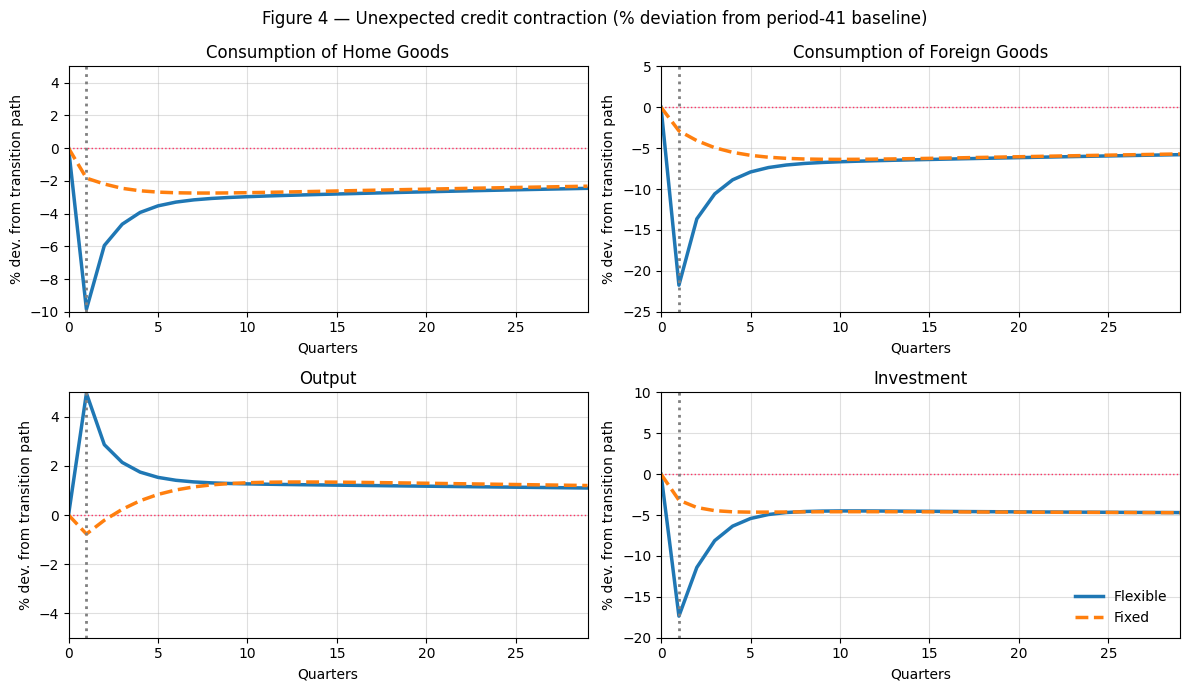

In [3]:
x = np.arange(Tirf)
FLEX = dict(color='C0', linestyle='-', linewidth=2.5, label='Flexible')
FIXED = dict(color='C1', linestyle='--', linewidth=2.5, label='Fixed')
ZERO_LINE = dict(color=(1.0, 0.2, 0.4), linestyle=':', linewidth=1)
VERT_LINE = dict(color=(0.5, 0.5, 0.5), linestyle=':', linewidth=2)

def pct_log(seq_T, base):
    """100*(log([base; seq(0:Tirf-2)]) - log(base)) — length Tirf."""
    head = np.array([base])
    return 100.0 * (np.log(np.concatenate([head, seq_T[:Tirf - 1]])) - np.log(base))

def pct_lin(seq_T, base):
    head = np.array([base])
    return 100.0 * (np.concatenate([head, seq_T[:Tirf - 1]]) - base) / base

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Figure 4 — Unexpected credit contraction (% deviation from period-41 baseline)', fontsize=12)

# (1,1) Consumption of Home Goods
ax = axes[0, 0]
ax.axhline(0, **ZERO_LINE)
ax.plot(x, pct_log(fl_s['c_t'], ch_agg0), **FLEX)
ax.plot(x, pct_log(fi_s['c_t'], ch_agg0), **FIXED)
ax.axvline(1, **VERT_LINE)
ax.set_title('Consumption of Home Goods')
ax.set_xlabel('Quarters'); ax.set_ylabel('% dev. from transition path')
ax.set_xlim(0, Tirf - 1); ax.set_ylim(-10, 5); ax.grid(True, alpha=0.4)

# (1,2) Consumption of Foreign Goods
ax = axes[0, 1]
ax.axhline(0, **ZERO_LINE)
ax.plot(x, pct_log(fl_s['c_foreign'], cf_agg0), **FLEX)
ax.plot(x, pct_log(fi_s['c_foreign'], cf_agg0), **FIXED)
ax.axvline(1, **VERT_LINE)
ax.set_title('Consumption of Foreign Goods')
ax.set_xlabel('Quarters'); ax.set_ylabel('% dev. from transition path')
ax.set_xlim(0, Tirf - 1); ax.set_ylim(-25, 5); ax.grid(True, alpha=0.4)

# (2,1) Output
ax = axes[1, 0]
ax.axhline(0, **ZERO_LINE)
ax.plot(x, pct_log(fl_s['y_agg'], y_agg0), **FLEX)
ax.plot(x, pct_log(fi_s['y_agg'], y_agg0), **FIXED)
ax.axvline(1, **VERT_LINE)
ax.set_title('Output')
ax.set_xlabel('Quarters'); ax.set_ylabel('% dev. from transition path')
ax.set_xlim(0, Tirf - 1); ax.set_ylim(-5, 5); ax.grid(True, alpha=0.4)

# (2,2) Investment
ax = axes[1, 1]
ax.axhline(0, **ZERO_LINE)
ax.plot(x, pct_lin(fl_s['inv'], inv0), **FLEX)
ax.plot(x, pct_lin(fi_s['inv'], inv0), **FIXED)
ax.axvline(1, **VERT_LINE)
ax.set_title('Investment')
ax.set_xlabel('Quarters'); ax.set_ylabel('% dev. from transition path')
ax.set_xlim(0, Tirf - 1); ax.set_ylim(-20, 10); ax.grid(True, alpha=0.4)
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
fig4_path_repo = FIGS_DIR / 'deFerra2020_fig4.png'
fig4_path_local = OUTPUT_DIR / 'deFerra2020_fig4.png'
fig.savefig(fig4_path_repo, dpi=150, bbox_inches='tight')
fig.savefig(fig4_path_local, dpi=150, bbox_inches='tight')
print(f'Saved Fig 4: {fig4_path_repo.resolve()}')
plt.show()

## Plot Figure 5

Note on “Nominal Exchange Rate”: under our pricing convention, the nominal exchange rate is $1/\text{tot}$ for flexible FX and $1$ (constant) for fixed. We follow MATLAB's `Figures.m` lines 351–352.

Saved Fig 5: /Users/siyingli/github/de-Ferra2020-kz/Figures/deFerra2020_fig5.png


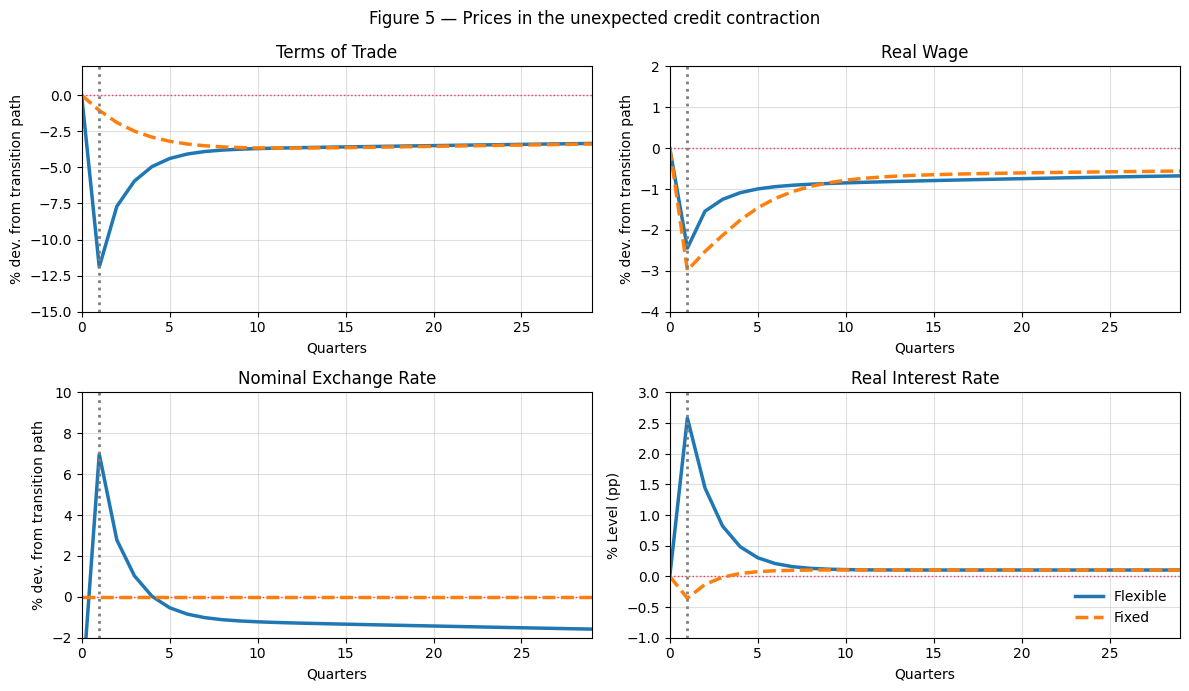

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Figure 5 — Prices in the unexpected credit contraction', fontsize=12)

# (1,1) Terms of Trade
ax = axes[0, 0]
ax.axhline(0, **ZERO_LINE)
ax.plot(x, pct_log(fl_s['tot'], tot0), **FLEX)
ax.plot(x, pct_log(fi_s['tot'], tot0), **FIXED)
ax.axvline(1, **VERT_LINE)
ax.set_title('Terms of Trade')
ax.set_xlabel('Quarters'); ax.set_ylabel('% dev. from transition path')
ax.set_xlim(0, Tirf - 1); ax.set_ylim(-15, 2); ax.grid(True, alpha=0.4)

# (1,2) Real Wage
ax = axes[0, 1]
ax.axhline(0, **ZERO_LINE)
ax.plot(x, pct_log(fl_s['w_r'], w0), **FLEX)
ax.plot(x, pct_log(fi_s['w_r'], w0), **FIXED)
ax.axvline(1, **VERT_LINE)
ax.set_title('Real Wage')
ax.set_xlabel('Quarters'); ax.set_ylabel('% dev. from transition path')
ax.set_xlim(0, Tirf - 1); ax.set_ylim(-4, 2); ax.grid(True, alpha=0.4)

# (2,1) Nominal Exchange Rate: 1/tot for flex; 1 (constant) for fixed
ax = axes[1, 0]
ax.axhline(0, **ZERO_LINE)
head = np.array([1.0 / tot0])
flex_e = np.concatenate([head, 1.0 / fl_s['tot'][:Tirf - 1]])
ax.plot(x, 100.0 * (np.log(flex_e) - np.log(tot0)), **FLEX)   # MATLAB does -log(tot0) here, see line 351
ax.plot(x, 100.0 * (np.log(np.ones(Tirf)) - np.log(1.0)), **FIXED)
ax.axvline(1, **VERT_LINE)
ax.set_title('Nominal Exchange Rate')
ax.set_xlabel('Quarters'); ax.set_ylabel('% dev. from transition path')
ax.set_xlim(0, Tirf - 1); ax.set_ylim(-2, 10); ax.grid(True, alpha=0.4)

# (2,2) Real Interest Rate (level dev. in pp; r0 subtracted)
ax = axes[1, 1]
ax.axhline(0, **ZERO_LINE)
head = np.array([0.0])
flex_dr = np.concatenate([head, 100.0 * (fl_s['r_t'][1:Tirf] - r0)])
fixed_dr = np.concatenate([head, 100.0 * (fi_s['r_t'][1:Tirf] - r0)])
ax.plot(x, flex_dr, **FLEX)
ax.plot(x, fixed_dr, **FIXED)
ax.axvline(1, **VERT_LINE)
ax.set_title('Real Interest Rate')
ax.set_xlabel('Quarters'); ax.set_ylabel('% Level (pp)')
ax.set_xlim(0, Tirf - 1); ax.set_ylim(-1, 3); ax.grid(True, alpha=0.4)
ax.legend(loc='lower right', frameon=False)

plt.tight_layout()
fig5_path_repo = FIGS_DIR / 'deFerra2020_fig5.png'
fig5_path_local = OUTPUT_DIR / 'deFerra2020_fig5.png'
fig.savefig(fig5_path_repo, dpi=150, bbox_inches='tight')
fig.savefig(fig5_path_local, dpi=150, bbox_inches='tight')
print(f'Saved Fig 5: {fig5_path_repo.resolve()}')
plt.show()

## Phase D timing summary

In [5]:
elapsed_total = time.perf_counter() - tic_total
elapsed_flex = float(fl['elapsed_seconds'])
elapsed_fixed = float(fi['elapsed_seconds'])

print('=== Phase D wall-clock summary ===')
print(f'  Notebook 12 (flex contraction, fsolve):     {elapsed_flex:7.1f} s = {elapsed_flex/60:5.2f} min')
print(f'  Notebook 13 (fixed-FX contraction, LM):     {elapsed_fixed:7.1f} s = {elapsed_fixed/60:5.2f} min')
print(f'  Notebook 14 (Figs 4-5 plotting):            {elapsed_total:7.1f} s = {elapsed_total/60:5.2f} min')
print(f'  Phase D total (12 + 13 + 14):               {elapsed_flex + elapsed_fixed + elapsed_total:7.1f} s = {(elapsed_flex+elapsed_fixed+elapsed_total)/60:5.2f} min')

=== Phase D wall-clock summary ===
  Notebook 12 (flex contraction, fsolve):       326.6 s =  5.44 min
  Notebook 13 (fixed-FX contraction, LM):      1185.1 s = 19.75 min
  Notebook 14 (Figs 4-5 plotting):                0.6 s =  0.01 min
  Phase D total (12 + 13 + 14):                1512.3 s = 25.21 min
